# Chương 3: Từ và Vectơ Từ (Words and Word Vectors)

Chương này trả lời hai câu hỏi nền tảng trong NLP:
- **Tokenization:** Chuỗi ký tự → chuỗi từ/token như thế nào?
- **Word Representation:** Biểu diễn từ dưới dạng số để máy tính xử lý như thế nào?

---

# 3.1 Tokenization (Phân Tách Từ)

**Tokenization** = thêm ranh giới từ vào chuỗi ký tự đầu vào.

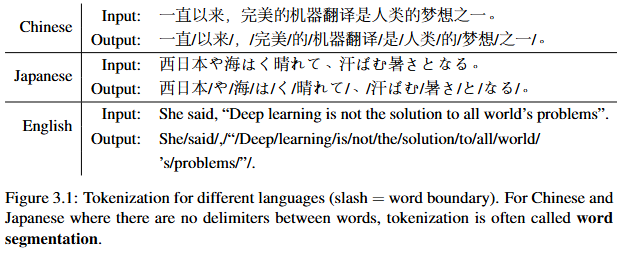

**Thách thức đa ngôn ngữ:**
- Tiếng Anh: có dấu cách nhưng vẫn cần xử lý dấu câu, từ ghép, v.v.
- Tiếng Trung/Nhật: **không có dấu cách** → word segmentation là bài toán khó hơn nhiều
- Analytic languages (Trung): ít biến đổi hình thái, phụ thuộc thứ tự từ
- Synthetic languages (Pháp): biến đổi hình thái phong phú, nghĩa phụ thuộc morphology

---

## 3.1.1 Tokenization bằng Quy Tắc và Heuristics

**Cách tiếp cận:** Định nghĩa tập quy tắc dựa trên kiến thức ngôn ngữ học. Ví dụ cho tiếng Anh:
- Tách bằng dấu cách → "word candidates"
- Chuỗi chỉ gồm chữ cái a-z, A-Z → là một từ
- Dấu câu (`,`, `.`, `"`) → tách thành token riêng
- `'s` → token riêng (possessive)

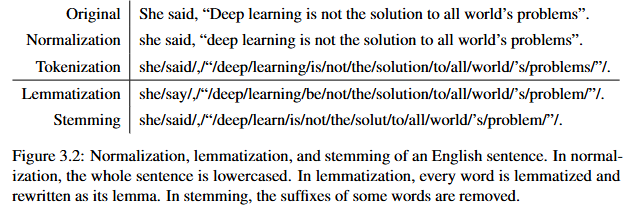

**Normalization** trước tokenization:
- Lowercase: "Deep" → "deep"
- Chuẩn hóa ký tự Unicode

**Lemmatization** — ánh xạ từ về dạng gốc (lemma), **phụ thuộc ngữ cảnh**:
```
learning → learn
learns   → learn
best     → good   (ngữ cảnh quyết định)
```

**Stemming** — cắt suffix, **không phụ thuộc ngữ cảnh**, kết quả không nhất thiết là từ hợp lệ:
```
removing → remov
removal  → remov
```

> **Hạn chế:** Quy tắc tay không mở rộng được sang ngôn ngữ không có dấu cách, cũng không tự thích nghi với dữ liệu mới. → Cần phương pháp thống kê.

---

## 3.1.2 Tokenization như Language Modeling

### Bài Toán

Cho chuỗi ký tự $x = x_1\ldots x_l$, tìm chuỗi từ $y = y_1\ldots y_m$ tốt nhất:

$$\hat{y} = \arg\max_y \log\Pr(y|x) \tag{3.2}$$

Vì $y$ xác định hoàn toàn $x$ (segmentation là deterministic), bài toán đơn giản thành:

$$\hat{y} = \arg\max_y \log\Pr(y) = \arg\max_y \log\Pr(y_1,\ldots,y_m) \tag{3.3}$$

→ Đây là bài toán **language modeling**!

### Ước Lượng Xác Suất

Dùng xấp xỉ n-gram:

$$\log\Pr(y_1,\ldots,y_m) = \sum_{i=1}^m \log\Pr(y_i \mid y_{i-n+1},\ldots,y_{i-1}) \tag{3.4, 3.5}$$

### Hai Vấn Đề Thực Tế

**1. Length bias:** $\Pr(y)$ thiên về chuỗi ngắn. Thêm length reward:

$$\hat{y} = \arg\max_y \log\Pr(y) + \lambda \cdot m \tag{3.6}$$

**2. Tìm kiếm hiệu quả** — exponentially many candidates. Dùng **dynamic programming**:

$$p(j+1) = \max_{1 \leq i \leq j} p(i) \cdot \Pr(w_{[i+1,j]}) \tag{3.8}$$

Độ phức tạp $O(l^2)$ với $l$ là độ dài chuỗi.

---

## 3.1.3 Tokenization như Sequence Labeling

**Ý tưởng:** Gán nhãn cho từng ký tự để đánh dấu ranh giới từ.

**Tập nhãn phổ biến:**

| Tập nhãn | Ý nghĩa |
|---|---|
| `{I, B}` | B = đầu từ, I = trong từ |
| `{I, B, E}` | + E = cuối từ |
| `{I, B1, B2, E}` | B1/B2 = ký tự thứ 1/2 của từ |

**Ví dụ:** 机器翻译/是/人类...

```
{I,B}: B I I I  B  B I  B ...
       机 器 翻 译  是  人 类  的 ...
```

**Bài toán:** Tìm label sequence tốt nhất:

$$\hat{c} = \arg\max_c \log\Pr(c \mid x) \tag{3.10}$$

Dùng Bayes' rule:

$$\hat{c} = \arg\max_c \log\Pr(x \mid c) + \log\Pr(c) \tag{3.11}$$

Đây là framework tổng quát — áp dụng được cho POS tagging, NER, và nhiều sequence labeling tasks khác.

---

## 3.1.4 Học Subword Units

### Tại Sao Cần Subword?

**Vấn đề của word-level tokenization:**
- **Rare words:** "uncopyrightable" xuất hiện rất ít → OOV (out-of-vocabulary)
- **Cố định vocabulary:** không học được segmentation tối ưu cho ML
- **Data sparsity:** vocabulary lớn, nhiều từ thấy ít

**Giải pháp:** Học các đơn vị **subword** — không nhất thiết là đơn vị ngôn ngữ học, nhưng tối ưu cho ML.

---

### 1. Byte Pair Encoding (BPE)

**Ý tưởng:** Lặp đi lặp lại merge cặp ký tự **xuất hiện nhiều nhất** thành symbol mới.

**Quy trình:**

**Bước 1 — Khởi tạo** từ character-level:
```
flow# : 2,  blow# : 2,  flat# : 1,  flag# : 4
Vocabulary: f,l,o,w,b,a,t,g,#
```

**Bước 2 — Đếm bigram và merge nhiều nhất:**
```
Bigrams: fl:7, la:5, lo:4, ow:4, ...
→ Merge "fl" → "fl" (tần suất 7)
```

**Bước 3 — Lặp lại:**
```
Merge "fl a" → "fla" (tần suất 5)
Merge "o w" → "ow" ...
```

Sau 6 lần merge:

```
Vocabulary: l,#,f,fl,a,fla,o,w,g,ow,ow#,flag,flag#,b,t
Word list:  fl ow#,  b l ow#,  fla t #,  flag#
```

**Áp dụng BPE vào text mới** "tow a flag":

```
t o w # a # f l a g #
→ fl       (merge fl)
→ fla      (merge fla)
→ ow       (merge ow)
→ ow#      (merge ow#)
→ flag#    (merge flag#)
= t ow# a # flag#
```

**Merge rule của BPE:**
$$(\hat{x}_i, \hat{x}_{i+1}) = \arg\max_{i} \text{count}(x_i, x_{i+1}) \tag{3.12}$$

---

### 2. WordPiece

**Giống BPE** nhưng khác ở **tiêu chí chọn bigram** — thay vì tần suất cao nhất, chọn bigram **tăng log-likelihood nhiều nhất**:

$$(\hat{x}_i, \hat{x}_{i+1}) = \arg\max_i \left[\log\Pr(x_i, x_{i+1}) - \log\Pr(x_i) - \log\Pr(x_{i+1})\right] \tag{3.13}$$

Số hạng $\log\Pr(x_i,x_{i+1}) - \log\Pr(x_i)\Pr(x_{i+1})$ chính là **Pointwise Mutual Information (PMI)** — đo mức độ hai symbol "thích xuất hiện cùng nhau" hơn mức ngẫu nhiên.

> **Khác biệt thực tế:** BPE thiên về merge các ký tự phổ biến. WordPiece thiên về merge các cặp có quan hệ thống kê mạnh hơn, ngay cả khi tần suất thấp hơn.

WordPiece được dùng trong **BERT**.

---

### 3. SentencePiece + Unigram LM

**Vấn đề với BPE và WordPiece:** Cần pre-tokenize thành từ trước → phụ thuộc vào word segmentation.

**SentencePiece:** Xử lý **raw text trực tiếp**, kể cả dấu cách là ký tự bình thường → language-independent.

**Unigram Language Model** — hướng ngược lại BPE:
- **BPE:** bottom-up (merge dần từ nhỏ → lớn)
- **Unigram:** top-down (bắt đầu vocabulary lớn → cắt bớt)

**Mô hình xác suất:** Xác suất của chuỗi subword $y$:

$$\Pr(y) = \prod_{i=1}^{|y|} \Pr(y_i) \tag{3.14}$$

Log-likelihood của toàn corpus:

$$\Pr(X) = \sum_{x \in X} \log \sum_{y \in Y(x)} \prod_{i=1}^{|y|} \Pr(y_i) \tag{3.17}$$

Tổng $\sum_{y \in Y(x)}$ xét **tất cả cách tokenize có thể** → regularization tự nhiên, tránh overfit vào một cách tokenize cụ thể.

**Quy trình SentencePiece:**
1. Khởi tạo vocabulary lớn (enumerate all substrings)
2. Ước lượng $\Pr(y)$ bằng EM algorithm
3. Tính loss của từng entry (nếu xóa entry này, likelihood giảm bao nhiêu)
4. Xóa ~20% entry có loss nhỏ nhất (ít ảnh hưởng nhất)
5. Lặp lại đến khi vocabulary đủ nhỏ

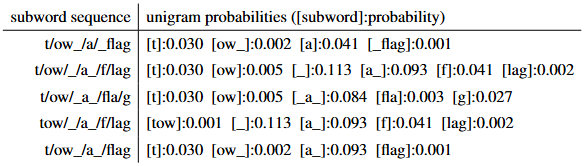

---

## So Sánh Ba Phương Pháp Subword

| | BPE | WordPiece | SentencePiece/Unigram |
|---|---|---|---|
| **Hướng** | Bottom-up | Bottom-up | Top-down |
| **Tiêu chí merge** | Tần suất | PMI (log-likelihood) | Giảm likelihood |
| **Pre-tokenize** | Cần | Cần | **Không cần** |
| **Xét nhiều cách tokenize** | Không | Không | **Có** (regularization) |
| **Dùng trong** | GPT, RoBERTa | BERT | SentencePiece (T5, LLaMA) |

---

## Tổng Kết Mục 3.1

```
Tokenization
├── Rule-based: đơn giản, không mở rộng được
│   └── Lemmatization, Stemming
├── Language Modeling: tokenize = tìm segmentation có Pr(y) lớn nhất
│   └── Dynamic programming O(l²)
├── Sequence Labeling: gán nhãn B/I/E cho từng ký tự
│   └── Tổng quát hóa sang POS tagging, NER
└── Subword Learning: học đơn vị tối ưu cho ML
    ├── BPE: merge theo tần suất
    ├── WordPiece: merge theo PMI (BERT)
    └── SentencePiece/Unigram: prune vocabulary, xét tất cả cách tokenize (T5, LLaMA)
```

> **Xu hướng hiện đại:** Hầu hết LLM dùng subword tokenization (BPE hoặc SentencePiece) vì cân bằng tốt giữa vocabulary size, OOV handling, và hiệu quả tính toán. Vocabulary size thường 30K–100K subword tokens.

# 3.2 Biểu Diễn Vectơ cho Từ (Vector Representation for Words)

---

## Bối Cảnh

Từ mang **ý nghĩa** — nhưng ý nghĩa là khái niệm nhận thức, không thể dùng trực tiếp trong tính toán. NLP cần **hình thức hóa** nghĩa từ thành dạng máy tính xử lý được.

---

## 3.2.1 Biểu Diễn One-hot

**Cách đơn giản nhất:** Mỗi từ = một số nguyên (dictionary ID). Dạng tương đương là one-hot vector — kích thước bằng vocabulary size, chỉ có đúng một vị trí bằng 1:

```
sparrow (id=8331):
[0  0  ...  0  1  0  ...  0  0]
                ↑
             id=8331
```

**Nhược điểm cốt lõi:** Mọi cặp từ đều **trực giao** với nhau → không thể đo quan hệ ngữ nghĩa. Cosine similarity của bất kỳ hai one-hot vector nào cũng = 0, dù "cat" và "dog" gần nghĩa hơn "cat" và "democracy" rất nhiều.

---

## 3.2.2 Biểu Diễn Phân Tán (Distributed Representation)

### Bước Đầu — Dùng Định Nghĩa Từ Điển

Ý tưởng: dùng **nội dung định nghĩa** của từ để tạo vector.

Ví dụ: sparrow → "a common, small, gray-brown bird" → bag-of-words vector:

```
[0  0  ...  1  ...  1  ...  1  ...  1  ...  0  0]
             ↑        ↑        ↑        ↑
           bird    brown    common    small
```

Cuckoo → "a grey bird with a two-note call..." → cũng có "bird" = 1 → cosine similarity > 0 → hai từ **được nhận ra là tương tự**!

**Hạn chế:** Phụ thuộc vào từ điển thủ công, không scale được.

### Biểu Diễn Thực Sự — Word Embedding

**Distributed representation (word embedding):** Vectơ thực nhiều chiều, không nhất thiết có thể giải thích được:

```
sparrow: [1.9  -7  3  -1.2  ...  2.01  -2.05]
```

Mỗi chiều encode một "thuộc tính" ẩn của từ — học được từ dữ liệu, không phải thiết kế tay.

**Triết lý cốt lõi:** Thay vì hỏi "vector này tốt không", hỏi "**nhóm** các vector có cư xử đúng không" — từ tương tự → vector gần nhau trong không gian.

### Hai Chiến Lược Học Word Embedding

**1. Học như byproduct:** Train một hệ thống lớn (language model, machine translation,...), embedding được học đồng thời. Sau training, bỏ phần còn lại, giữ embedding function để dùng.

**2. Học chuyên biệt:** Thiết kế mô hình tập trung vào word representation learning — ví dụ Word2Vec, GloVe (Mục 3.4, 3.5).

---

## 3.2.3 Tính Tổ Hợp và Tính Ngữ Cảnh

### Tính Tổ Hợp (Compositionality)

> *"Ý nghĩa của một biểu thức phức tạp được xác định bởi cấu trúc của nó và ý nghĩa của các thành phần cấu tạo."*

Ví dụ đơn giản: nghĩa của "white cat" = kết hợp nghĩa của "white" + "cat".

**Trong word embedding:** Ta muốn vector biểu diễn có **tính tổ hợp tuyến tính**. Thực tế, nhiều mô hình nơ-ron học được điều này, ví dụ nổi tiếng:

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

> **Giới hạn:** Compositionality phá vỡ ở **thành ngữ** (idioms) và **collocation** — "kick the bucket" không có nghĩa là "đá cái xô". Đây là lý do NLP khó.

### Tính Ngữ Cảnh (Contextuality)

**Polysemy (đa nghĩa):** Cùng một từ, nghĩa khác nhau tùy ngữ cảnh:

```
"They sat round the dinner table"     → table = mặt phẳng (bàn)
"This table represents export sales"  → table = bảng dữ liệu
```

**Homonymy:** Từ có nhiều lexeme khác nhau — "bear" (gấu) vs "bear" (chịu đựng).

**Hệ quả cho NLP:** Word embedding tĩnh (static) — một từ = một vector duy nhất — **không thể** xử lý polysemy.

**Giải pháp:** **Contextual representation** — mô hình sinh ra vector khác nhau cho cùng một từ tùy theo ngữ cảnh xung quanh. Đây là nền tảng của BERT, GPT (Chương 4-6).

---

## Tổng Kết Mục 3.2

```
One-hot
  + Đơn giản, unique identity
  - Trực giao, không có ngữ nghĩa
        ↓
Dictionary-based BOW
  + Chia sẻ thông tin ngữ nghĩa
  - Phụ thuộc từ điển thủ công
        ↓
Word Embedding (Distributed Representation)
  + Học được từ dữ liệu
  + Từ tương tự → vector gần nhau
  - Một từ = một vector (static)
        ↓
Contextual Representation (BERT, GPT)
  + Cùng từ, ngữ cảnh khác → vector khác
  + Xử lý được polysemy
  (Chương 4-6)
```

| Thuộc tính | One-hot | Static Embedding | Contextual Embedding |
|---|---|---|---|
| Ngữ nghĩa | ✗ | ✓ (partial) | ✓ |
| Tính tổ hợp | ✗ | ✓ (partial) | ✓ |
| Xử lý đa nghĩa | ✗ | ✗ | ✓ |
| Chi phí tính toán | Thấp | Thấp | Cao |

> **Kết nối:** Mục 3.2 đặt nền tảng khái niệm. Mục 3.3-3.5 sẽ đi vào các phương pháp cụ thể học static word embedding (Word2Vec, GloVe). Chương 4-6 sẽ học contextual embedding (Transformer, BERT, GPT).

# 3.3 Mô Hình Dựa trên Đếm (Count-based Models)

---

## Giả Thuyết Phân Phối (Distributional Hypothesis)

> *"Từ có ngữ nghĩa tương tự nếu chúng xuất hiện trong các ngữ cảnh tương tự."* — Harris (1954), Firth (1957)

Đây là nền tảng của toàn bộ mục 3.3: **ý nghĩa của từ = phân phối của từ trong ngữ cảnh**.

---

## 3.3.1 Ma Trận Đồng Xuất Hiện (Co-occurrence Matrices)

### Word-Word Co-occurrence Matrix

Đếm số lần mỗi cặp từ xuất hiện cùng nhau trong corpus → ma trận $|V| \times |V|$:

| | flowering | fruit | herbaceous | often | plants | seeds |
|---|---|---|---|---|---|---|
| **berry** | 1 | 3 | 1 | 1 | 1 | 1 |
| **banana** | 1 | 2 | 1 | 0 | 2 | 1 |
| **teeth** | 0 | 0 | 0 | 0 | 0 | 1 |

Mỗi hàng = word vector của từ đó. Từ có phân phối tương tự → góc giữa hai vectơ nhỏ → **cosine similarity cao**.

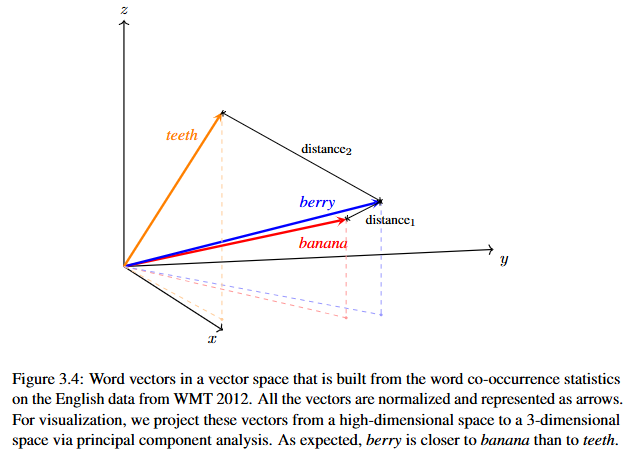

**Context window:** Thay vì dùng toàn bộ document, chỉ đếm trong cửa sổ $\pm k$ từ xung quanh — tương quan giảm khi khoảng cách tăng.

### Pointwise Mutual Information (PMI)

Thay vì dùng raw count, đo **mức độ hai từ xuất hiện cùng nhau nhiều hơn ngẫu nhiên**:

$$\text{PMI}(a, b) = \log \frac{\Pr(a, b)}{\Pr(a)\Pr(b)} \tag{3.21}$$

- $\text{PMI} > 0$: hai từ xuất hiện cùng nhau **nhiều hơn** kỳ vọng ngẫu nhiên
- $\text{PMI} = 0$: độc lập thống kê
- $\text{PMI} < 0$: ít hơn kỳ vọng (thường bị clip về 0 → PPMI)

Word vector dựa trên PMI:

$$e(a) = [\text{PMI}(a, b_1),\ \ldots,\ \text{PMI}(a, b_{|V|})] \tag{3.22}$$

> **Lưu ý:** PMI không ổn định với từ hiếm — nếu từ rất hiếm tình cờ xuất hiện cùng nhau, PMI sẽ rất lớn một cách giả tạo.

### Word-Document Co-occurrence Matrix (Term-Document Matrix)

Thay vì đếm đồng xuất hiện giữa hai từ, đếm từ xuất hiện trong từng document → ma trận $|V| \times |D|$:

| | Doc 1 | Doc 2 | Doc 3 | Doc 4 | Doc 5 |
|---|---|---|---|---|---|
| **berry** | 1 | 1 | 0 | 0 | 1 |
| **banana** | 0 | 0 | 1 | 1 | 1 |
| **teeth** | 0 | 0 | 0 | 1 | 0 |

**Term Frequency (TF)** — các dạng biến thể:

| Dạng | Công thức |
|---|---|
| Binary | $\mathbf{1}[a \in d]$ |
| Count | $\text{count}(a; d)$ |
| Exponential | $\text{count}(a; d)^\alpha$ |
| Log-scale | $\log(1 + \text{count}(a; d))$ |
| Normalized | $\text{count}(a;d) / \sum_{a'}\text{count}(a';d)$ |

---

## 3.3.2 TF-IDF

**Vấn đề với TF đơn thuần:** Từ phổ biến trong toàn corpus (như "the", "is") có TF cao ở mọi document → không phân biệt được document.

**Giải pháp — TF-IDF:**

$$\text{tfidf}(a, d, D) = \text{tf}(a, d) \cdot \text{idf}(a, D) \tag{3.23}$$

**Inverse Document Frequency (IDF):**

$$\text{idf}(a, D) = \log \frac{|D|}{\text{df}(a, D)} \tag{3.24}$$

$$\text{idf}_{\text{smoothed}}(a, D) = \log \frac{|D|}{\text{df}(a, D) + 1} + 1 \tag{3.25}$$

Trong đó $\text{df}(a, D)$ = số document chứa từ $a$.

**Cơ chế:**
- Từ **hiếm, đặc trưng** cho document: TF cao + IDF cao → TF-IDF cao ✓
- Từ **phổ biến** toàn corpus: TF có thể cao nhưng IDF rất nhỏ → TF-IDF nhỏ ✓
- Từ **không có** trong document: TF = 0 → TF-IDF = 0 ✓

**Ứng dụng:** Information Retrieval — biểu diễn query và document bằng TF-IDF vector, tính relevance qua cosine similarity.

---

## 3.3.3 Mô Hình Chiều Thấp (Low-Dimensional Models)

**Vấn đề:** Co-occurrence matrix rất lớn — ví dụ 20,000 từ × 10,000,000 documents = $2 \times 10^{11}$ entries. Không thực tế để làm việc trực tiếp.

**Giải pháp:** Giảm chiều về $r^* \ll |V|$ hoặc $|D|$.

---

### 1. Latent Semantic Analysis (LSA)

**Ý tưởng:** Dùng SVD để phân tích co-occurrence matrix → tìm "cấu trúc ngữ nghĩa ẩn".

Cho $M \in \mathbb{R}^{|V| \times |D|}$ là term-document matrix:

$$M = P\Sigma Q^\top \tag{3.26}$$

trong đó $P \in \mathbb{R}^{|V| \times r}$, $\Sigma \in \mathbb{R}^{r \times r}$ (diagonal), $Q \in \mathbb{R}^{|D| \times r}$.

**Biểu diễn từ và document:**
- Hàng $i$ của $P$ → word vector $e_i$ của từ $a_i$
- Hàng $j$ của $Q$ → document vector $h_j$ của document $d_j$

**Low-rank approximation** — chỉ giữ $r^*$ singular values lớn nhất:

$$M \approx \sum_{i=1}^{r^*} \sigma_i \mathbf{p}_i \mathbf{q}_i^\top \tag{3.34}$$

> **Kết nối với SVD (Chương 4 MML):** Đây chính xác là truncated SVD / Eckart-Young theorem — xấp xỉ hạng $r^*$ tối ưu theo spectral norm. $\sigma_1 \geq \sigma_2 \geq \ldots \geq \sigma_r$ → giữ $r^*$ lớn nhất bảo toàn thông tin quan trọng nhất.

**Diễn giải:** Các singular value lớn tương ứng với các "chủ đề" quan trọng nhất trong corpus. LSA tìm không gian ngữ nghĩa ẩn ($r^*$ chiều) nằm sau co-occurrence statistics.

---

### 2. Principal Component Analysis (PCA)

**Ý tưởng:** Tìm các hướng trong không gian đặc trưng có **variance lớn nhất** → chiếu dữ liệu lên đó.

Cho $M \in \mathbb{R}^{|V| \times |D|}$ (mỗi hàng = word vector $|D|$ chiều), PCA tìm ánh xạ tuyến tính:

$$N = MC \tag{3.35}$$

trong đó $C \in \mathbb{R}^{|D| \times p}$ là ma trận $p$ principal component coefficients.

**Tìm $\hat{c}_i$** — hướng tối đa hóa variance:

$$\hat{c}_i = \arg\max_{c_i} \text{Var}(Mc_i) = \arg\max_{c_i} c_i^\top S c_i \tag{3.38}$$

với $S$ là ma trận hiệp phương sai của $M$, ràng buộc $c_i^\top c_i = 1$.

Dùng Lagrange multiplier:

$$\mathcal{L}(c_i, \lambda_i) = c_i^\top S c_i - \lambda_i(c_i^\top c_i - 1) \tag{3.39}$$

Đặt gradient = 0 → $S\hat{c}_i = \lambda_i \hat{c}_i$ → **$\hat{c}_i$ là eigenvector của $S$, $\lambda_i$ là eigenvalue tương ứng**.

Chọn $p$ eigenvector ứng với $p$ eigenvalue lớn nhất → $p$ principal components.

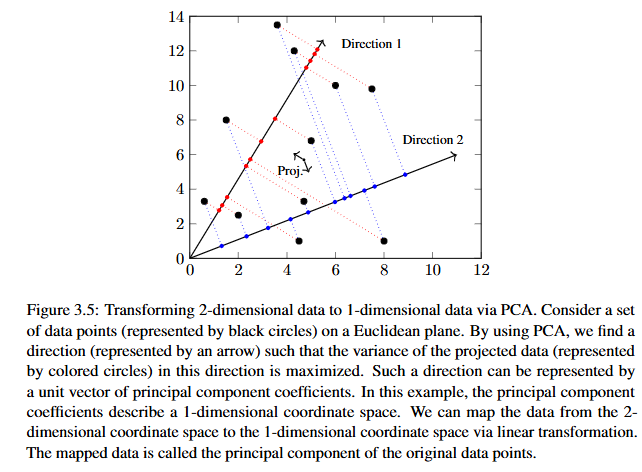

> **Kết nối với Chương 4 MML:** PCA = eigendecomposition của ma trận hiệp phương sai $S$. Các principal component coefficients = eigenvectors của $S$. Eigenvalue lớn → hướng quan trọng hơn.

**PCA vs LSA:**
- Cả hai đều giảm chiều tuyến tính
- LSA dùng SVD trực tiếp trên $M$; PCA dùng eigendecomposition của covariance matrix
- Toán học tương đương nhau trong nhiều trường hợp, nhưng diễn giải khác nhau

---

### 3. Các Phương Pháp Khác

**Topic Models (LDA):** Mô hình generative — document được sinh từ phân phối topic, topic được sinh từ phân phối từ. Cho $K$ topic, thu được ma trận $|V| \times K$ → word representation $K$ chiều. Không phổ biến cho word representation hiện đại.

**Auto-encoders:** Encode co-occurrence features vào chiều thấp không cần giả định về cấu trúc ẩn (xem Mục 2.6).

**Supervised Dimensionality Reduction:** Khi có nhãn — Fisher's Linear Discriminant, Linear Discriminant Analysis (LDA) tìm không gian tối đa hóa khoảng cách giữa các lớp.

**Feature Selection:** Chọn subset đặc trưng quan trọng nhất thay vì kết hợp chúng. Thường cần nhãn để đánh giá.

---

## Tổng Kết Mục 3.3

```
Distributional Hypothesis: nghĩa từ = phân phối trong ngữ cảnh

Ma trận đồng xuất hiện
├── Word-Word: đếm cùng xuất hiện giữa các từ
│   └── Dùng PMI thay raw count → đo tương quan thực sự
└── Word-Document (TF-IDF): đếm từ trong document
    ├── TF: từ quan trọng với document
    └── IDF: phạt từ phổ biến toàn corpus
    
Giảm chiều (từ |V|×|D| → |V|×r*)
├── LSA (SVD): giữ r* singular values lớn nhất
│   → "chủ đề ẩn" trong corpus
├── PCA (Eigendecomposition): giữ p hướng variance lớn nhất
│   → tương đương LSA về mặt toán học
└── Topic Models, Auto-encoders,...
```

| Phương pháp | Đầu vào | Kỹ thuật | Chiều đầu ra |
|---|---|---|---|
| Raw co-occurrence | Text | Đếm | $|V|$ hoặc $|D|$ |
| TF-IDF | Text | TF × IDF | $|D|$ |
| LSA | TF-IDF matrix | SVD | $r^* \ll |D|$ |
| PCA | Co-occurrence matrix | Eigendecomposition | $p \ll |D|$ |
| Word2Vec/GloVe | Text | Neural (Mục 3.4-3.5) | $d_e \approx$ 100-300 |

> **Hạn chế của count-based models:** Vector chiều cao, sparse, không nắm bắt được quan hệ phức tạp. → Mục 3.4-3.5 sẽ trình bày **neural word embedding** (Word2Vec, GloVe) — học trực tiếp từ dữ liệu, dense, và thường tốt hơn nhiều trong thực tế.

# 3.4 Học Word Embedding từ Neural Language Models (NLMs)

---

## Hạn Chế của Count-based Models

Count-based models (Mục 3.3) ràng buộc cứng: mỗi entry của word vector phải là bằng chứng **giải thích được** về cách từ phân phối trong ngữ cảnh (count, PMI, TF-IDF,...).

**Mục tiêu tốt hơn:** Học vectơ **dày đặc, thực** (dense, real-valued) không cần ràng buộc cố định — để mô hình tự khám phá đặc trưng tốt nhất từ dữ liệu.

**Thách thức:** Không có nhãn ground-truth cho word vectors → không thể học trực tiếp.

**Giải pháp:** Học word vectors như **byproduct** của một bài toán có sẵn (background task) — phổ biến nhất là **Neural Language Modeling**.

---

## Kiến Trúc — NLM Pre-training

Nhắc lại NLM từ Mục 2.2: dự đoán $w_i$ từ $n-1$ từ ngữ cảnh trước đó.

**Embedding layer** — biến đổi one-hot sang dense vector:

$$e_j = \mathbf{1}_{w_j} \cdot C \tag{3.40}$$

trong đó $C \in \mathbb{R}^{|V| \times d_e}$ là **word embedding table** — hàng thứ $k$ là vector của từ thứ $k$.

**Feed-forward network** — tính phân phối xác suất:

$$\Pr(\cdot \mid w_{i-n+1}, \ldots, w_{i-1}) = F_{\theta, C}(w_{i-n+1}, \ldots, w_{i-1}) \tag{3.42}$$

**Hàm mục tiêu training** — maximum likelihood:

$$(\hat{\theta}, \hat{C}) = \arg\max_{\theta, C} \sum_{i=n}^m \log \Pr_{\theta,C}(w_i \mid w_{i-n+1}, \ldots, w_{i-1}) \tag{3.43}$$

Tối ưu đồng thời cả $\theta$ (tham số mạng) và $C$ (embedding table).

---

## Pre-training và Transfer

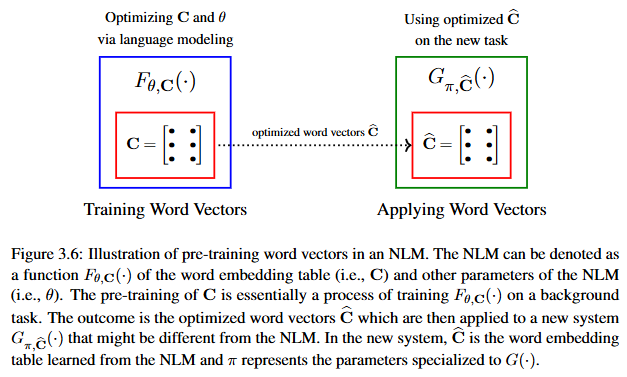

**Sau khi train xong:**
- Bỏ phần còn lại của NLM
- Giữ lại $\hat{C}$ — word embedding table đã được tối ưu
- Dùng $\hat{C}$ cho hệ thống khác $G_{\pi,\hat{C}}(\cdot)$ — có thể hoàn toàn khác NLM

**Đây chính là paradigm pre-training:**
1. Train trên background task lớn (language modeling) với nhiều dữ liệu không nhãn
2. Tái sử dụng $\hat{C}$ cho downstream task — ít dữ liệu hơn, không cần train lại embedding từ đầu

**Rủi ro:** Word vectors tốt nhất cho NLM chưa chắc tốt nhất cho downstream task → thường cần **fine-tuning** thêm.

**Thực tế:** Word vectors pre-trained từ NLM thường là điểm khởi đầu tốt cho nhiều task, ngay cả khi không fine-tune.

---

## Tổng Kết Mục 3.4

```
Vấn đề: Cần word vectors tốt nhưng không có nhãn

Giải pháp — học như byproduct:
  Background task: Language Modeling
       ↓
  Train F_{θ,C}(·): predict từ tiếp theo
       ↓
  Thu được Ĉ (embedding table đã tối ưu)
       ↓
  Tái sử dụng Ĉ cho downstream tasks
```

> **Kết nối:** Mục 3.4 trình bày ý tưởng tổng quát — học embedding từ NLM. Mục 3.5 sẽ đi vào các phương pháp **chuyên biệt** hơn để học word embedding hiệu quả hơn (Word2Vec, GloVe) — không cần train full NLM mà chỉ tập trung vào việc học word vectors.

# 3.5 Các Mô Hình Word Embedding

---

## 3.5.1 Word2Vec — CBOW và Skip-gram

Word2Vec gồm hai mô hình **đơn giản, hiệu quả** học word embedding từ ngữ cảnh cục bộ. Không cần hidden layer phức tạp — chỉ embedding + Softmax.

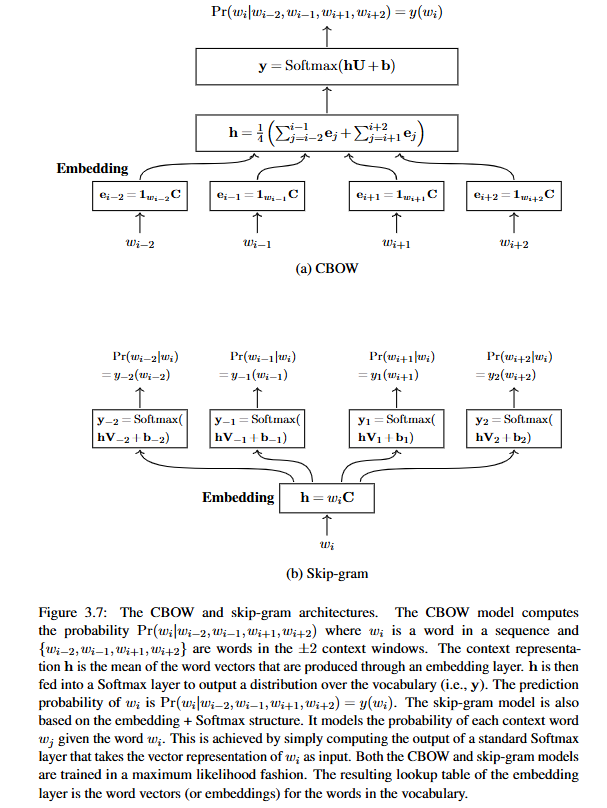

---

### CBOW (Continuous Bag-of-Words)

**Nhiệm vụ:** Dự đoán từ trung tâm $w_i$ từ các từ ngữ cảnh xung quanh $\{w_{i-n},\ldots,w_{i-1},w_{i+1},\ldots,w_{i+n}\}$.

**Bước 1 — Embedding:** Chuyển các từ ngữ cảnh thành dense vectors, lấy **trung bình**:

$$h = \frac{1}{2n}\left(\sum_{j=i-n}^{i-1} \mathbf{1}_{w_j}C + \sum_{j=i+1}^{i+n} \mathbf{1}_{w_j}C\right) \tag{3.44}$$

> **"Bag-of-Words":** Phép tính trung bình **bỏ qua thứ tự** của các từ ngữ cảnh — chỉ quan tâm đến từ nào xuất hiện, không quan tâm thứ tự.

**Bước 2 — Softmax output:**

$$y = \text{Softmax}(hU + b), \quad \Pr(w_i \mid \text{context}) = y(w_i) \tag{3.45}$$

**Hàm mục tiêu:**

$$(\hat{\theta}, \hat{C}) = \arg\max_{\theta,C} \sum_{i=n+1}^{m-n-1} \log \Pr_{\theta,C}(w_i \mid w_{i-n},\ldots,w_{i-1},w_{i+1},\ldots,w_{i+n}) \tag{3.46}$$

Sau training: bỏ $\hat{\theta} = \{U, b\}$, giữ $\hat{C}$ làm word embedding table.

---

### Skip-gram

**Nhiệm vụ:** Ngược lại CBOW — dự đoán các từ ngữ cảnh $w_{i+k}$ từ từ trung tâm $w_i$.

**Bước 1 — Embedding từ trung tâm:**

$$h = \mathbf{1}_{w_i} C \tag{3.47}$$

**Bước 2 — Dự đoán từng vị trí ngữ cảnh riêng lẻ** (mỗi vị trí $k$ có bộ tham số riêng $V_k, b_k$):

$$y_k = \text{Softmax}(hV_k + b_k), \quad \Pr(w_{i+k} \mid w_i) = y_k(w_{i+k}) \tag{3.48, 3.49}$$

**Hàm mục tiêu:**

$$(\hat{\theta}, \hat{C}) = \arg\max_{\theta,C} \sum_{i} \sum_{-n \leq k \leq n,\ k \neq 0} \log \Pr_{\theta,C}(w_{i+k} \mid w_i) \tag{3.50}$$

---

### So Sánh CBOW và Skip-gram

| | CBOW | Skip-gram |
|---|---|---|
| **Nhiệm vụ** | Context → từ trung tâm | Từ trung tâm → Context |
| **Input** | Trung bình các context vectors | Vector của từ trung tâm |
| **Tốt với** | Từ phổ biến, corpus lớn | Từ hiếm, corpus nhỏ |
| **Tốc độ** | Nhanh hơn | Chậm hơn |

**Điểm chung quan trọng:**
- Cả hai đều là **log-linear models**: input → linear transform → dense vector → log-linear classification (Softmax)
- **Không có hidden layer** → nhanh, scale tốt
- Mục tiêu không phải dự đoán từ chính xác, mà là **học word vectors** tốt

---

## 3.5.2 GloVe (Global Vectors)

**Ý tưởng:** Kết hợp ưu điểm của count-based (global statistics) và neural (dense vectors) — học trực tiếp từ **tỷ lệ xác suất đồng xuất hiện**.

### Động Lực — Tỷ Lệ Xác Suất

Xét bài toán phân biệt "air" và "water" qua các từ probe $w$:

| Probe $w$ | $\Pr(\text{air}\|w)$ | $\Pr(\text{water}\|w)$ | Tỷ lệ |
|---|---|---|---|
| fly | $1.5\times10^{-4}$ | $1.3\times10^{-5}$ | **11.54** (air) |
| drink | $6.2\times10^{-5}$ | $4.1\times10^{-4}$ | **0.15** (water) |
| live | $1.6\times10^{-4}$ | $1.4\times10^{-4}$ | **1.14** (cả hai) |
| flow | $3.6\times10^{-4}$ | $3.0\times10^{-4}$ | **1.2** (cả hai) |

> **Insight then chốt:** **Tỷ lệ** $\Pr(\text{air}\|w)/\Pr(\text{water}\|w)$ phân biệt rõ hơn giá trị tuyệt đối. Word vectors nên encode tỷ lệ này.

### Suy Dẫn Công Thức GloVe

**Bước 1 — Đặt hàm $F$ encode tỷ lệ:**

$$F(e_a, e_b, \tilde{e}_w) = \frac{\Pr(a\mid w)}{\Pr(b\mid w)} \tag{3.52}$$

$e_a, e_b$: target vectors (từ $C$); $\tilde{e}_w$: context vector (từ $\tilde{C}$ riêng biệt — tránh overfitting).

**Bước 2 — Không gian vectơ là tuyến tính** → encode quan hệ qua hiệu:

$$F\!\left((e_a - e_b)\tilde{e}_w^\top\right) = \frac{\Pr(a\mid w)}{\Pr(b\mid w)} \tag{3.53}$$

**Bước 3 — $F$ phải là homomorphism** (cộng vectơ → nhân xác suất):

$$F\!\left((e_a - e_b)\tilde{e}_w^\top\right) = \frac{F(e_a\tilde{e}_w^\top)}{F(e_b\tilde{e}_w^\top)} \tag{3.54}$$

Nghiệm duy nhất: $F(x) = \exp(x)$.

**Bước 4 — Thay vào và lấy logarithm:**

$$e_a\tilde{e}_w^\top = \log\text{count}(a,w) - \log\text{count}(a) \tag{3.56}$$

**Bước 5 — Khôi phục tính đối xứng** (hoán đổi target/context không đổi geometry) bằng bias terms:

$$e_a\tilde{e}_w^\top + \beta_a + \tilde{\beta}_w = \log\text{count}(a, w) \tag{3.57}$$

### Hàm Mục Tiêu GloVe

**Loss từng cặp $(a, w)$** — hồi quy bình phương:

$$L_{a,w} = \left(e_a\tilde{e}_w^\top + \beta_a + \tilde{\beta}_w - \log\text{count}(a,w)\right)^2 \tag{3.58}$$

**Tổng loss có trọng số:**

$$L_{\text{GloVe}} = \sum_{a,w \in V} f(\text{count}(a,w)) \cdot L_{a,w} \tag{3.59}$$

**Hàm trọng số** — phạt cặp từ hiếm, giới hạn cặp từ quá phổ biến:

$$f(x) = \begin{cases}\left(\frac{x}{x_{\max}}\right)^\alpha & \text{nếu } x < x_{\max} \\ 1 & \text{ngược lại}\end{cases}, \quad x_{\max}=100,\ \alpha=3/4 \tag{3.60}$$

**Word vector cuối cùng:**

$$e_{\text{final}} = C + \tilde{C}$$

(trung bình hoặc tổng target và context embeddings)

> **Ưu điểm của GloVe:** Dùng **squared loss** thay cross-entropy → không cần Softmax → **train nhanh hơn** Word2Vec. Tối ưu hóa trực tiếp trên global co-occurrence statistics → hiệu quả hơn online SGD của Word2Vec.

---

## 3.5.3 Nhận Xét Tổng Quan

### 1. Count-based vs Neural Network-based

| | Count-based (LSA, TF-IDF) | Neural (Word2Vec, GloVe) |
|---|---|---|
| **Biểu diễn** | Sparse, high-dim | Dense, low-dim |
| **Tính giải thích** | Cao (entries có nghĩa rõ) | Thấp (latent features) |
| **Vấn đề** | Curse of dimensionality, sparse | Cần nhiều dữ liệu để train |
| **Phù hợp** | Cần interpretability | Tích hợp vào deep networks |

Cả hai đều dựa trên **distributional hypothesis** — không có loại nào tuyệt đối tốt hơn, phụ thuộc task.

### 2. Shallow vs Deep Models

**Shallow (Word2Vec, GloVe):**
- 1-2 lớp, **không có hidden layer phi tuyến**
- Cực kỳ hiệu quả về tính toán → scale tốt
- Ví dụ: **fastText** — CBOW + output layer → phân loại văn bản, train rất nhanh

**Deep Models:**
- Hypothesis space lớn hơn, nắm bắt pattern phức tạp hơn
- Cho **contextual embeddings** — cùng từ, ngữ cảnh khác → vector khác
- BERT, GPT (Chương 4-6) — state-of-the-art nhưng tốn kém hơn nhiều

### 3. Training Objectives

**Hai hướng thiết kế:**

**Dùng NLP task có sẵn:** word prediction (CBOW, Skip-gram), language modeling, text classification → word vectors là tham số mô hình, tối ưu end-to-end.

**Thiết kế objective mới:** CBOW/Skip-gram là ví dụ — "word prediction" là proxy task, không phải mục tiêu cuối cùng, nhưng học được biểu diễn tốt.

**Self-supervised learning:** Không cần nhãn người annotate → scale lên corpus khổng lồ → nền tảng của pre-training hiện đại.

---

## Tổng Kết Mục 3.5

```
Word2Vec
├── CBOW: context → từ trung tâm
│   h = mean(context embeddings) → Softmax
│   Tốt với từ phổ biến, nhanh
└── Skip-gram: từ trung tâm → context
    h = embedding(từ trung tâm) → nhiều Softmax
    Tốt với từ hiếm

GloVe
  Học từ global co-occurrence matrix
  Objective: ea·ẽw + βa + β̃w = log count(a,w)
  Dùng squared loss + weighting → train nhanh

Đặc điểm chung:
- Cả hai đều: log-linear, không hidden layer phức tạp
- Không học contextual embedding (1 từ = 1 vector)
- Nền tảng cho contextual models (BERT, GPT) ở Chương 4-6
```

# 3.6 Đánh Giá Word Embeddings

Sau khi học được word vectors, cần đánh giá **chất lượng** của chúng. Không có gold standard tuyệt đối → dùng hai hướng tiếp cận bổ sung cho nhau.

---

## 3.6.1 Đánh Giá Ngoại Tại (Extrinsic Evaluation)

**Ý tưởng:** Tích hợp word vectors vào hệ thống NLP thực tế, đo hiệu suất của **toàn hệ thống**.

**Hai chế độ sử dụng:**

| Chế độ | Mô tả | Ưu điểm |
|---|---|---|
| **Fixed parameters** | Đóng băng word vectors, chỉ train phần còn lại | Đánh giá trực tiếp chất lượng embedding |
| **Fine-tuning** | Dùng pre-trained vectors làm khởi tạo, tiếp tục train | Vectors thích nghi với task cụ thể |

**Hạn chế:** Kết quả phụ thuộc nặng vào kiến trúc và task cụ thể → khó phân biệt đóng góp của embedding và các yếu tố khác. Cần test trên **nhiều task đa dạng** để kết luận.

---

## 3.6.2 Đánh Giá Nội Tại (Intrinsic Evaluation)

Kiểm tra trực tiếp khả năng của word vectors trong việc nắm bắt **các tính chất ngôn ngữ cụ thể**.

### 1. Độ Tương Đồng Ngữ Nghĩa (Semantic Relatedness)

**Ý tưởng:** Khoảng cách hình học trong vector space phải tương quan với đánh giá của con người về độ gần nghĩa.

**Đánh giá:**
- Dataset gồm các cặp từ + điểm similarity do người annotate (thang Likert 1-5)
- Tính cosine similarity giữa hai word vectors
- Đo **tương quan** giữa điểm người và điểm mô hình (Pearson/Spearman correlation)

**Thách thức:**
- "Semantic relatedness" vs "semantic similarity" khác nhau — car/road thì related nhưng không similar; car/van thì similar
- Polysemy: "bank" (ngân hàng) và "bank" (bờ sông) cùng một vector nhưng nghĩa khác nhau
- Static embeddings: 1 từ = 1 vector → không xử lý được đa nghĩa

### 2. Bài Toán Phép Loại Suy Từ (Word Analogy)

**Ý tưởng:** Quan hệ ngữ nghĩa giữa các từ có thể nắm bắt bằng **phép tính vectơ tuyến tính**.

Ví dụ nổi tiếng (Mikolov et al., 2013):

$$e_{\text{king}} - e_{\text{man}} + e_{\text{woman}} \approx e_{\text{queen}} \tag{3.61}$$

**Formalization:** Hai cặp từ $(a, a^*)$ và $(b, b^*)$ có cùng quan hệ nếu:

$$e_{a^*} - e_a \approx e_{b^*} - e_b \tag{3.62}$$

**Task:** Cho $e_a$, $e_{a^*}$, $e_b$ → dự đoán $e_{b^*}$ là từ nào trong vocabulary.

Các loại phép loại suy phổ biến:
- **Quan hệ quốc gia-thủ đô:** Paris:France = Berlin:Germany
- **Quan hệ giới tính:** king:man = queen:woman
- **Quan hệ thì động từ:** walked:walk = ran:run

> **Tính chất nổi bật:** Word embedding models học được tính chất tuyến tính này **mà không được training để đạt điều đó** — đây là emergent property, cho thấy cấu trúc ngữ nghĩa ẩn trong dữ liệu.

**Hạn chế:** Accuracy trên word analogy không luôn tương quan tốt với downstream NLP performance → dùng như công cụ phân tích, không phải metric duy nhất.

### 3. Phân Nhóm Từ (Word Categorization / Clustering)

**Ý tưởng:** Từ cùng semantic category nên cluster với nhau.

Ví dụ: {apple, grape, peach, orange} → cluster "fruits".

**Cách thực hiện:** Áp dụng clustering algorithms (k-means, hierarchical...) lên word vectors → so sánh với human-defined categories.

**Ưu điểm:** Đánh giá **cấu trúc toàn cục** của vector space, không chỉ từng cặp riêng lẻ.

**Hạn chế:** Phải xác định trước số cluster; semantic taxonomy có tính chủ quan cao.

### 4. Đánh Giá Tiềm Thức (Subconscious / Cognitive Evaluation)

**Ý tưởng:** Tương quan vector similarity với **phản ứng tâm lý của người đọc**.

**Priming experiments:** Đo thời gian đọc từ target sau từ prime — nếu "dog" làm người đọc xử lý "wolf" nhanh hơn, chứng tỏ hai từ có liên hệ mạnh trong não.

**Neuroimaging:** fMRI, EEG đo hoạt động não khi đọc → tương quan với word vectors.

**Hạn chế:** Hiểu biết về cơ chế nhận thức còn hạn chế → khó liên kết trực tiếp với NLP performance.

### 5. Đánh Giá Dựa trên Ngôn Ngữ Học (Linguistically Motivated Evaluation)

**Ý tưởng:** Word vectors nên phản ánh kiến thức ngôn ngữ trong các nguồn tài nguyên có sẵn.

- So sánh với định nghĩa từ điển
- Đánh giá theo WordNet (mạng quan hệ ngữ nghĩa)
- Dùng graph-based algorithms đo alignment với semantic networks

---

## 3.6.3 Trực Quan Hóa (Visualization)

Chiếu word vectors từ không gian chiều cao xuống 2D/3D để quan sát trực quan:

**PCA:** Ánh xạ tuyến tính, tìm hướng variance lớn nhất (Mục 3.3.3).

**t-SNE (t-distributed Stochastic Neighbor Embedding):** Phương pháp **phi tuyến** — bảo toàn cấu trúc cục bộ (láng giềng gần nhau trong chiều cao → gần nhau trong 2D). Phổ biến hơn PCA cho visualization vì thể hiện cluster rõ hơn.

---

## 3.7 Tổng Kết Chương 3

### Hai Bài Toán Cốt Lõi

**1. Tokenization** — chia văn bản thành units:

```
Rule-based → Language Modeling → Sequence Labeling → Subword
    ↑                                                      ↑
Đơn giản,                                        BPE, WordPiece,
không scale                                      SentencePiece
                                                 (BERT, GPT, T5)
```

Xu hướng hiện đại: subword tokenization (BPE/SentencePiece) — không phụ thuộc linguistic rules, scale tốt, xử lý được OOV.

**2. Word Representation** — biểu diễn từ dưới dạng vectơ:

```
One-hot (sparse)
    ↓ (định nghĩa từ điển)
Bag-of-words count vector (sparse, high-dim)
    ↓ (distributional hypothesis)
Co-occurrence matrix → TF-IDF → LSA/PCA (dense, low-dim)
    ↓ (neural approach)
Word2Vec (CBOW, Skip-gram), GloVe (dense, low-dim, learned)
    ↓ (contextual)
BERT, GPT — contextual embeddings (Chương 4-6)
```

### Các Điểm Quan Trọng

**Distributional Hypothesis** (nền tảng toàn chương):
> *"Từ xuất hiện trong ngữ cảnh tương tự → nghĩa tương tự"*

**Static vs Contextual Embeddings:**
- Static (Word2Vec, GloVe): 1 từ = 1 vector, nhanh, không xử lý polysemy
- Contextual (BERT, GPT): cùng từ, ngữ cảnh khác → vector khác, mạnh hơn nhưng đắt hơn

**Pre-training paradigm:**
- Train trên background task lớn → học representations tốt
- Tái sử dụng cho downstream tasks → ít cần labeled data hơn

**Đánh giá:**
- Extrinsic: downstream task performance (thực tế nhất)
- Intrinsic: semantic relatedness, word analogy, clustering (diagnostic)

### Kết Nối với Các Chương Tiếp Theo

| Chương | Chủ đề | Kết nối |
|---|---|---|
| Chương 4 | Transformer, Attention | Contextual word embeddings |
| Chương 5 | Pre-trained LMs (BERT, GPT) | Word vectors → sentence representations |
| Chương 6 | Large Language Models | Scale pre-training lên toàn bộ ngôn ngữ |
| Chương 7 | Sentence Representations | Auto-encoder cho sentences |